# 04 · Placebo inference: is the lift real?

**Question:** a 6-state test returns **+6.9%**. Could that be noise? What range of true effects is consistent with it?

**Answer:** in 1,000 placebo tests on untreated states, noise never reached 6.9% (max 5.8%): **p < 0.001**, 95% CI **[2.8%, 10.5%]**, which covers the true 8%. With a true lift of 2%, the same design returns p = 0.76, so "not significant" here means *underpowered*, not *no effect*.

**Method (permutation / placebo test):** draw fake treatment groups **only from control states**, run the same DiD on data with **no** injected lift, repeat 1,000 times. The result is the distribution of "lift" that noise alone produces.

- p-value = share of placebos with |lift| ≥ |estimate| (two-sided)
- 95% CI = estimate − 97.5th percentile, estimate − 2.5th percentile of placebos (estimate = truth + noise, so truth = estimate − noise)

**Data:** GA4 Google Merchandise Store public sample (BigQuery `ga4_obfuscated_sample_ecommerce`), aggregated to sessions per US state per day, 2020-11-01 to 2021-01-31. Lifts are **injected** into real data (semi-synthetic), so the true effect is always known. Treated: Texas, Florida, Georgia, Arizona, Ohio, Michigan; true lift **8%** from 2021-01-04; 28 control states.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/ga4_state_daily.csv", parse_dates=["date"])
START = pd.Timestamp("2021-01-04")
WINDOW = pd.Timedelta(days=28)

wide = df.pivot(index="date", columns="state", values="sessions").fillna(0).astype(float)
daily_median = df.groupby("state").sessions.median()
wide = wide[daily_median[daily_median >= 10].index]

pre  = (wide.index >= START - WINDOW) & (wide.index < START)   # 12/07 – 01/03
post = (wide.index >= START) & (wide.index < START + WINDOW)   # 01/04 – 01/31

def did_lift(data, treated, control):
    T = data[treated].sum(axis=1)
    C = data[control].sum(axis=1)
    return (T[post].sum() / T[pre].sum()) / (C[post].sum() / C[pre].sum()) - 1

TREATED = ["Texas", "Florida", "Georgia", "Arizona", "Ohio", "Michigan"]
CONTROL = [s for s in wide.columns if s not in TREATED]
print(len(TREATED), "treated |", len(CONTROL), "control")

6 treated | 28 control


## Step 1 · The test result

In [2]:
TRUE_LIFT = 0.08
observed = wide.copy()
observed.loc[post, TREATED] *= 1 + TRUE_LIFT          # inject the lift

estimate = did_lift(observed, TREATED, CONTROL)
print(f"Estimated lift: {estimate:.1%}   (truth: {TRUE_LIFT:.0%})")

Estimated lift: 6.9%   (truth: 8%)


## Step 2 · Placebo distribution

Fake groups come only from control states, and placebos run on the un-injected data, so every placebo has a true effect of exactly 0. In a real experiment, restricting placebos to control units is what keeps them clean.

Placebo lifts: mean 0.4%, std 2.1%, range -4.7% to 5.8%


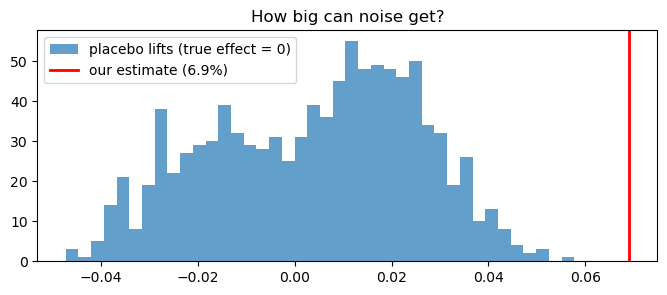

In [3]:
rng = np.random.default_rng(42)
placebos = []

for _ in range(1000):
    fake_treated = list(rng.choice(CONTROL, 6, replace=False))
    fake_control = [s for s in CONTROL if s not in fake_treated]
    placebos.append(did_lift(wide, fake_treated, fake_control))

placebos = np.array(placebos)
print(f"Placebo lifts: mean {placebos.mean():.1%}, std {placebos.std():.1%}, "
      f"range {placebos.min():.1%} to {placebos.max():.1%}")

plt.figure(figsize=(8, 3))
plt.hist(placebos, bins=40, alpha=0.7, label="placebo lifts (true effect = 0)")
plt.axvline(estimate, color="red", lw=2, label=f"our estimate ({estimate:.1%})")
plt.legend(); plt.title("How big can noise get?"); plt.show()

## Step 3 · p-value

In [4]:
p_value = np.mean(np.abs(placebos) >= abs(estimate))    # two-sided
print(f"p-value: {p_value:.3f}")

p-value: 0.000


With 1,000 placebos the smallest resolvable p-value is 0.001, so the result is reported as **p < 0.001**, not p = 0.

## Step 4 · 95% confidence interval

In [5]:
ci_low  = estimate - np.quantile(placebos, 0.975)
ci_high = estimate - np.quantile(placebos, 0.025)
print(f"Estimate {estimate:.1%}, 95% CI [{ci_low:.1%}, {ci_high:.1%}]")
print("Does the CI contain the true 8%?", ci_low <= TRUE_LIFT <= ci_high)
print("Does the CI contain 0?", ci_low <= 0 <= ci_high)

Estimate 6.9%, 95% CI [2.8%, 10.5%]
Does the CI contain the true 8%? True
Does the CI contain 0? False


## Step 5 · Smaller true lifts with the same design

In [6]:
rows = []
for lift in [0, 0.02, 0.05, 0.10]:
    obs = wide.copy()
    obs.loc[post, TREATED] *= 1 + lift
    est = did_lift(obs, TREATED, CONTROL)
    p = np.mean(np.abs(placebos) >= abs(est))
    lo, hi = est - np.quantile(placebos, 0.975), est - np.quantile(placebos, 0.025)
    rows.append({"true lift": lift, "estimate": est, "p-value": p, "CI low": lo, "CI high": hi})

pd.DataFrame(rows).style.format({c: "{:.1%}" for c in ["true lift", "estimate", "CI low", "CI high"]} | {"p-value": "{:.3f}"})

,true lift,estimate,p-value,CI low,CI high
0,0.0%,-1.0%,0.748,-5.1%,2.6%
1,2.0%,1.0%,0.757,-3.1%,4.6%
2,5.0%,3.9%,0.040,-0.1%,7.6%
3,10.0%,8.9%,0.000,4.8%,12.5%


## Findings

| | Result |
|---|---|
| Estimate (true lift 8%) | **6.9%** |
| Placebo noise | mean 0.4%, std **2.1%**, range −4.7% to +5.8% |
| p-value | **< 0.001** |
| 95% CI | **[2.8%, 10.5%]**: contains 8%, excludes 0 |

| True lift | Estimate | p-value | 95% CI | Significant? |
|---|---|---|---|---|
| 0% | −1.0% | 0.748 | [−5.1%, 2.6%] | No (correct) |
| 2% | 1.0% | 0.757 | [−3.1%, 4.6%] | No: real effect missed |
| 5% | 3.9% | 0.040 | [−0.1%, 7.6%] | Borderline |
| 10% | 8.9% | < 0.001 | [4.8%, 12.5%] | Yes |

- A simple rule predicts every row: this group carries about −1% of its own noise (estimate ≈ truth − 1%), and the estimate must exceed ~3.8% (95% of |placebo| values fall below it) to be significant.
- **A real 2% lift came out p = 0.76.** "Not significant" means the design can't see 2%, not that the ads failed.
- **At 5%, p-value and CI disagree** (p = 0.04, but the CI touches 0) because the noise distribution isn't symmetric (mean +0.4%). Near the edge, report the interval.
- The placebo distribution is lumpy, not bell-shaped. Permutation inference doesn't need a normality assumption.

## Implications

- Report a lift **with** its interval, never the point estimate alone.
- This design detects ~10% reliably and ~5% barely. Knowing that **before** launch is the minimum detectable effect → [05](05_power_analysis_mde.ipynb).